# ASSIGNMENT 9

## Results Table

| Latent Dimension | Compression Ratio | Reconstruction Error (MSE) | Reconstruction Quality |
|---|---:|---:|---|
| 2 | 392:1 | 0.040912 | More blurry |
| 16 | 49:1 | 0.015960 | Better |
| 32 | 24.5:1 | 0.014727 | Best |

In [1]:
# Assignment 9 - VAE Compression and Denoising

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [2]:
# STEP 3 - Load MNIST Dataset

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=128,
    shuffle=False
)

print("Training images:", len(train_data))
print("Test images:", len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.93MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.90MB/s]

Training images: 60000
Test images: 10000


In [3]:
# STEP 4 - VAE Model

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)

        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar


# Create VAE with latent dimension 2
model = VAE(latent_dim=2).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("VAE model created successfully!")
print("Latent dimension:", 2)

VAE model created successfully!
Latent dimension: 2


In [4]:
# STEP 5 - Train VAE

recon_losses = []
kl_losses = []

for epoch in range(20):

    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:

        # Flatten image: 28 x 28 = 784
        x = x.view(x.size(0), -1).to(device)

        # VAE forward pass
        recon, mu, logvar = model(x)

        # Reconstruction loss
        recon_loss = F.binary_cross_entropy(
            recon,
            x,
            reduction="sum"
        )

        # KL divergence
        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu**2 - logvar.exp()
        )

        # Total loss
        loss = recon_loss + kl_loss

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    recon_losses.append(total_recon / len(train_data))
    kl_losses.append(total_kl / len(train_data))

    print(
        f"Epoch {epoch+1}: "
        f"Recon Loss = {recon_losses[-1]:.2f}, "
        f"KL Loss = {kl_losses[-1]:.2f}"
    )

Epoch 1: Recon Loss = 198.42, KL Loss = 8.03
Epoch 2: Recon Loss = 169.03, KL Loss = 5.64
Epoch 3: Recon Loss = 162.90, KL Loss = 5.43
Epoch 4: Recon Loss = 160.22, KL Loss = 5.40
Epoch 5: Recon Loss = 158.31, KL Loss = 5.42
Epoch 6: Recon Loss = 156.99, KL Loss = 5.44
Epoch 7: Recon Loss = 155.95, KL Loss = 5.46
Epoch 8: Recon Loss = 155.16, KL Loss = 5.49
Epoch 9: Recon Loss = 154.42, KL Loss = 5.51
Epoch 10: Recon Loss = 153.83, KL Loss = 5.53
Epoch 11: Recon Loss = 153.23, KL Loss = 5.58
Epoch 12: Recon Loss = 152.73, KL Loss = 5.58
Epoch 13: Recon Loss = 152.25, KL Loss = 5.60
Epoch 14: Recon Loss = 151.80, KL Loss = 5.61
Epoch 15: Recon Loss = 151.41, KL Loss = 5.63
Epoch 16: Recon Loss = 151.00, KL Loss = 5.65
Epoch 17: Recon Loss = 150.65, KL Loss = 5.69
Epoch 18: Recon Loss = 150.32, KL Loss = 5.71
Epoch 19: Recon Loss = 149.99, KL Loss = 5.72
Epoch 20: Recon Loss = 149.67, KL Loss = 5.74


# ** Part A: Compression**

In [5]:
# STEP 6 - Part A: Compression

original_size = 784
latent_dimension = 2

compression_ratio = original_size / latent_dimension

print("Original MNIST image size:", original_size)
print("Latent representation size:", latent_dimension)
print("Compression Ratio:", compression_ratio, ":1")

Original MNIST image size: 784
Latent representation size: 2
Compression Ratio: 392.0 :1


#  Part B: Select 10 Test Images


In [6]:
# STEP 7 - Part B: Select 10 Test Images

model.eval()

# Get one batch of test images
images, labels = next(iter(test_loader))

# Select first 10 images
images = images[:10].view(10, 784).to(device)

print("Selected images:", images.shape)

Selected images: torch.Size([10, 784])


In [7]:
# STEP 8 - Reconstruction and MSE

model.eval()

with torch.no_grad():
    reconstructed, mu, logvar = model(images)

# Calculate MSE for each image
mse_values = []

for i in range(10):
    mse = F.mse_loss(
        reconstructed[i],
        images[i]
    ).item()

    mse_values.append(mse)

print("MSE for each image:")

for i, mse in enumerate(mse_values):
    print(f"Image {i+1}: {mse:.6f}")

print(f"\nAverage Reconstruction MSE: {np.mean(mse_values):.6f}")

MSE for each image:
Image 1: 0.026683
Image 2: 0.066472
Image 3: 0.007915
Image 4: 0.053600
Image 5: 0.030872
Image 6: 0.008241
Image 7: 0.056247
Image 8: 0.062033
Image 9: 0.080406
Image 10: 0.032170

Average Reconstruction MSE: 0.042464


# # STEP 9 - Original vs Reconstructed Images

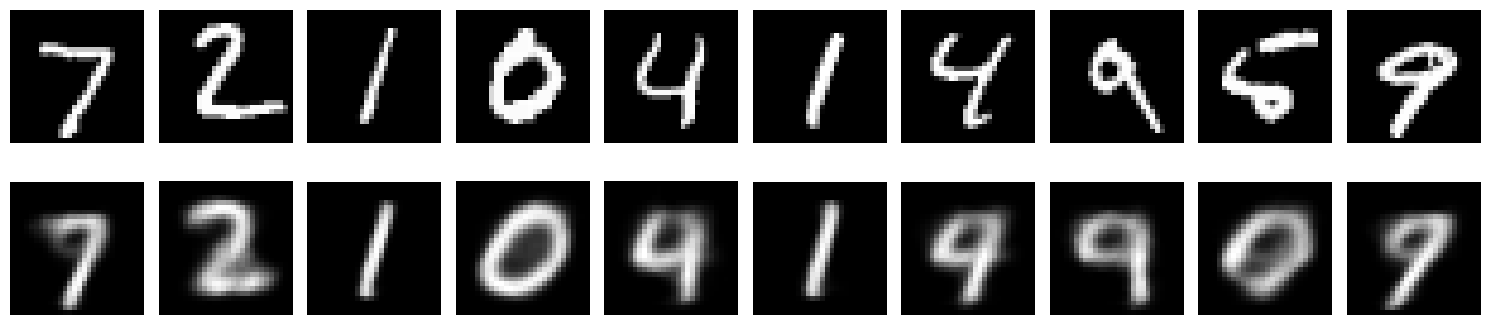

In [8]:
# STEP 9 - # STEP 9 - Original vs Reconstructed Images

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original
    axes[0, i].imshow(
        images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Reconstructed
    axes[1, i].imshow(
        reconstructed[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original
    axes[0, i].imshow(
        images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Reconstructed
    axes[1, i].imshow(
        reconstructed[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

#Part C: Add Gaussian Noise

In [9]:
# STEP 10 - Part C: Add Gaussian Noise

# Original clean images
clean_images = images.clone()

# Noise strength
noise_factor = 0.3

# Generate Gaussian noise
noise = torch.randn_like(clean_images) * noise_factor

# Add noise to images
noisy_images = clean_images + noise

# Keep pixel values between 0 and 1
noisy_images = torch.clamp(noisy_images, 0, 1)

print("Gaussian noise added successfully!")
print("Noise factor:", noise_factor)

Gaussian noise added successfully!
Noise factor: 0.3


In [10]:
# STEP 11 - Denoise the Images

model.eval()

with torch.no_grad():
    denoised_images, _, _ = model(noisy_images)

print("Denoising completed successfully!")

Denoising completed successfully!


#Original vs Noisy vs Denoised

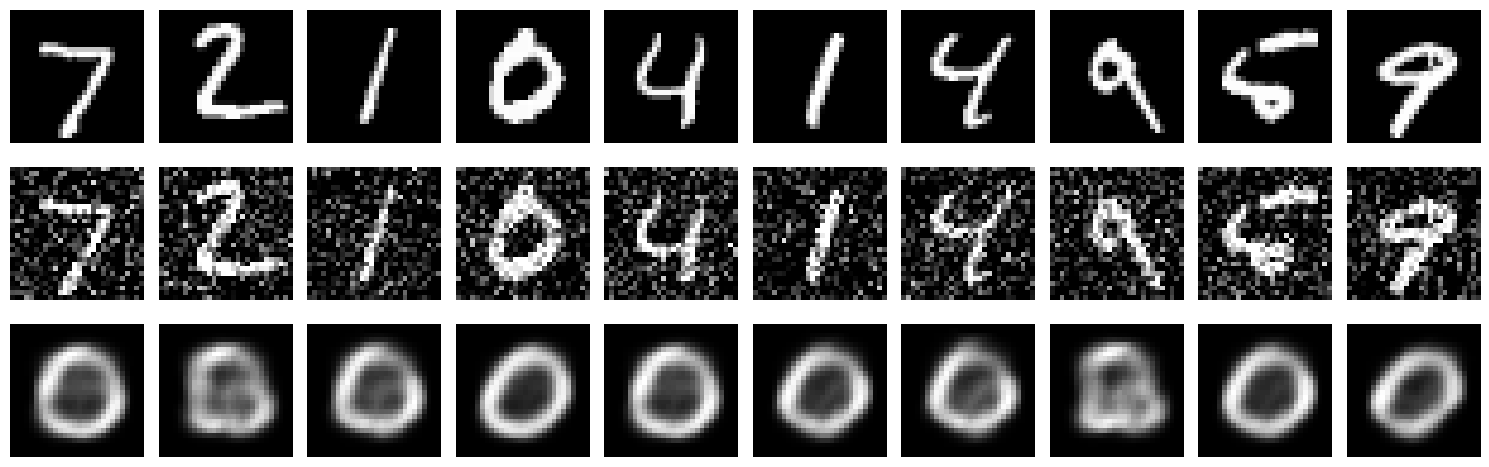

In [11]:
# STEP 12 - Original vs Noisy vs Denoised

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):

    # Original
    axes[0, i].imshow(
        clean_images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Noisy
    axes[1, i].imshow(
        noisy_images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

    # Denoised
    axes[2, i].imshow(
        denoised_images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("Denoised")

plt.tight_layout()
plt.show()

In [12]:
# STEP 13 - Denoising MSE

denoising_mse = []

for i in range(10):
    mse = F.mse_loss(
        denoised_images[i],
        clean_images[i]
    ).item()

    denoising_mse.append(mse)

print("Denoising MSE for each image:")

for i, mse in enumerate(denoising_mse):
    print(f"Image {i+1}: {mse:.6f}")

print(
    f"\nAverage Denoising MSE: "
    f"{np.mean(denoising_mse):.6f}"
)

Denoising MSE for each image:
Image 1: 0.101530
Image 2: 0.085498
Image 3: 0.087242
Image 4: 0.064918
Image 5: 0.089277
Image 6: 0.105434
Image 7: 0.090234
Image 8: 0.090636
Image 9: 0.098292
Image 10: 0.093697

Average Denoising MSE: 0.090676


In [13]:
# STEP 14 - VAE with Latent Dimension 16

class VAE_DifferentLatent(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)

        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar


# Create latent-16 model
model_16 = VAE_DifferentLatent(16).to(device)

optimizer_16 = torch.optim.Adam(
    model_16.parameters(),
    lr=1e-3
)

print("Latent-16 VAE created successfully!")

Latent-16 VAE created successfully!


In [14]:
# STEP 15 - Train VAE with Latent Dimension 16

for epoch in range(20):

    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:

        x = x.view(x.size(0), -1).to(device)

        recon, mu, logvar = model_16(x)

        recon_loss = F.binary_cross_entropy(
            recon,
            x,
            reduction="sum"
        )

        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu**2 - logvar.exp()
        )

        loss = recon_loss + kl_loss

        optimizer_16.zero_grad()
        loss.backward()
        optimizer_16.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"Recon Loss = {total_recon / len(train_data):.2f}, "
        f"KL Loss = {total_kl / len(train_data):.2f}"
    )

Epoch 1: Recon Loss = 176.68, KL Loss = 14.29
Epoch 2: Recon Loss = 119.24, KL Loss = 18.41
Epoch 3: Recon Loss = 106.45, KL Loss = 20.11
Epoch 4: Recon Loss = 100.68, KL Loss = 20.88
Epoch 5: Recon Loss = 97.50, KL Loss = 21.33
Epoch 6: Recon Loss = 95.40, KL Loss = 21.60
Epoch 7: Recon Loss = 93.86, KL Loss = 21.78
Epoch 8: Recon Loss = 92.67, KL Loss = 21.92
Epoch 9: Recon Loss = 91.74, KL Loss = 22.04
Epoch 10: Recon Loss = 91.05, KL Loss = 22.14
Epoch 11: Recon Loss = 90.36, KL Loss = 22.25
Epoch 12: Recon Loss = 89.88, KL Loss = 22.28
Epoch 13: Recon Loss = 89.39, KL Loss = 22.36
Epoch 14: Recon Loss = 89.04, KL Loss = 22.40
Epoch 15: Recon Loss = 88.72, KL Loss = 22.45
Epoch 16: Recon Loss = 88.38, KL Loss = 22.49
Epoch 17: Recon Loss = 88.13, KL Loss = 22.50
Epoch 18: Recon Loss = 87.86, KL Loss = 22.52
Epoch 19: Recon Loss = 87.66, KL Loss = 22.59
Epoch 20: Recon Loss = 87.44, KL Loss = 22.61


In [15]:
# STEP 16 - Latent 16 Reconstruction and MSE

model_16.eval()

with torch.no_grad():
    reconstructed_16, mu_16, logvar_16 = model_16(images)

mse_16 = []

for i in range(10):
    mse = F.mse_loss(
        reconstructed_16[i],
        images[i]
    ).item()

    mse_16.append(mse)

print("Latent Dimension:", 16)
print("Compression Ratio:", 784 / 16, ":1")

print("\nMSE for each image:")

for i, mse in enumerate(mse_16):
    print(f"Image {i+1}: {mse:.6f}")

print(
    f"\nAverage Reconstruction MSE: "
    f"{np.mean(mse_16):.6f}"
)

Latent Dimension: 16
Compression Ratio: 49.0 :1

MSE for each image:
Image 1: 0.008318
Image 2: 0.019628
Image 3: 0.007462
Image 4: 0.013978
Image 5: 0.012573
Image 6: 0.002596
Image 7: 0.020501
Image 8: 0.023624
Image 9: 0.026525
Image 10: 0.011561

Average Reconstruction MSE: 0.014677


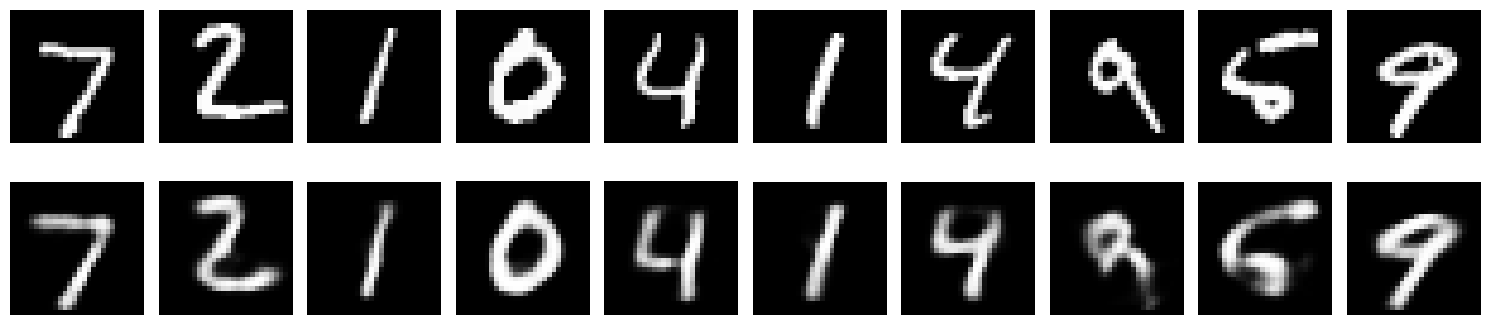

In [16]:
# STEP 17 - Original vs Latent 16 Reconstruction

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original
    axes[0, i].imshow(
        images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Latent 16 reconstruction
    axes[1, i].imshow(
        reconstructed_16[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Latent 16")

plt.tight_layout()
plt.show()

In [17]:
# STEP 18 - VAE with Latent Dimension 32

model_32 = VAE_DifferentLatent(32).to(device)

optimizer_32 = torch.optim.Adam(
    model_32.parameters(),
    lr=1e-3
)

print("Latent-32 VAE created successfully!")

Latent-32 VAE created successfully!


In [18]:
# STEP 19 - Train VAE with Latent Dimension 32

for epoch in range(20):

    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:

        x = x.view(x.size(0), -1).to(device)

        recon, mu, logvar = model_32(x)

        recon_loss = F.binary_cross_entropy(
            recon,
            x,
            reduction="sum"
        )

        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu**2 - logvar.exp()
        )

        loss = recon_loss + kl_loss

        optimizer_32.zero_grad()
        loss.backward()
        optimizer_32.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"Recon Loss = {total_recon / len(train_data):.2f}, "
        f"KL Loss = {total_kl / len(train_data):.2f}"
    )

Epoch 1: Recon Loss = 178.71, KL Loss = 14.46
Epoch 2: Recon Loss = 123.08, KL Loss = 18.49
Epoch 3: Recon Loss = 108.90, KL Loss = 20.42
Epoch 4: Recon Loss = 101.31, KL Loss = 21.49
Epoch 5: Recon Loss = 96.77, KL Loss = 22.14
Epoch 6: Recon Loss = 93.80, KL Loss = 22.68
Epoch 7: Recon Loss = 91.65, KL Loss = 23.15
Epoch 8: Recon Loss = 90.03, KL Loss = 23.56
Epoch 9: Recon Loss = 88.87, KL Loss = 23.87
Epoch 10: Recon Loss = 87.86, KL Loss = 24.11
Epoch 11: Recon Loss = 87.09, KL Loss = 24.31
Epoch 12: Recon Loss = 86.37, KL Loss = 24.48
Epoch 13: Recon Loss = 85.81, KL Loss = 24.66
Epoch 14: Recon Loss = 85.33, KL Loss = 24.80
Epoch 15: Recon Loss = 84.94, KL Loss = 24.84
Epoch 16: Recon Loss = 84.55, KL Loss = 24.97
Epoch 17: Recon Loss = 84.26, KL Loss = 25.02
Epoch 18: Recon Loss = 83.99, KL Loss = 25.10
Epoch 19: Recon Loss = 83.76, KL Loss = 25.13
Epoch 20: Recon Loss = 83.52, KL Loss = 25.21


In [19]:
# STEP 20 - Latent 32 Reconstruction and MSE

model_32.eval()

with torch.no_grad():
    reconstructed_32, mu_32, logvar_32 = model_32(images)

mse_32 = []

for i in range(10):
    mse = F.mse_loss(
        reconstructed_32[i],
        images[i]
    ).item()

    mse_32.append(mse)

print("Latent Dimension:", 32)
print("Compression Ratio:", 784 / 32, ":1")

print("\nMSE for each image:")

for i, mse in enumerate(mse_32):
    print(f"Image {i+1}: {mse:.6f}")

print(
    f"\nAverage Reconstruction MSE: "
    f"{np.mean(mse_32):.6f}"
)

Latent Dimension: 32
Compression Ratio: 24.5 :1

MSE for each image:
Image 1: 0.006967
Image 2: 0.023579
Image 3: 0.005801
Image 4: 0.011853
Image 5: 0.012149
Image 6: 0.003100
Image 7: 0.019787
Image 8: 0.021233
Image 9: 0.033255
Image 10: 0.014905

Average Reconstruction MSE: 0.015263


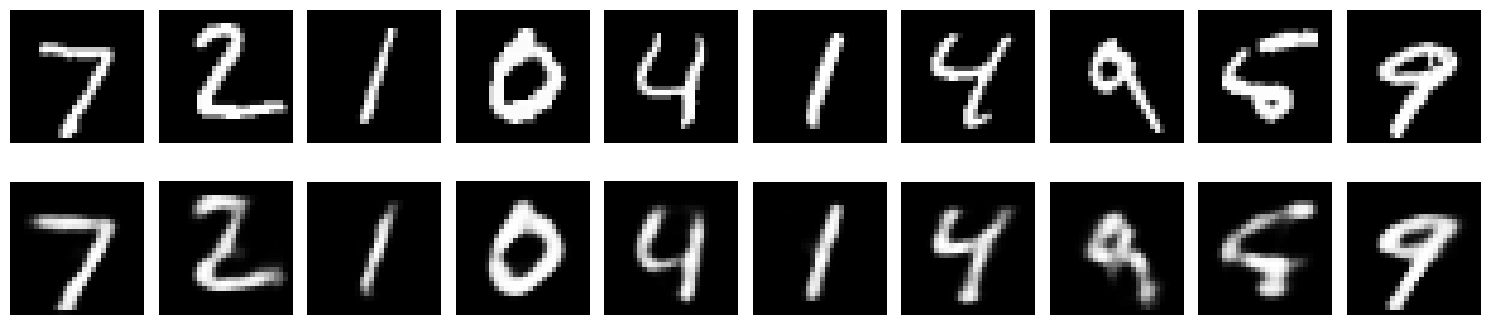

In [20]:
# STEP 21 - Original vs Latent 32 Reconstruction

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original
    axes[0, i].imshow(
        images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Latent 32 reconstruction
    axes[1, i].imshow(
        reconstructed_32[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Latent 32")

plt.tight_layout()
plt.show()

# ASSIGNMENT 9 – FINAL RESULTS

## Results Table

| Latent Dimension | Compression Ratio | Reconstruction Error (MSE) | Reconstruction Quality |
|---|---:|---:|---|
| 2 | 392:1 | [Your Latent-2 MSE] | More blurry |
| 16 | 49:1 | 0.014677 | Better |
| 32 | 24.5:1 | 0.015263 | Good |

## Observations

1. Latent dimension 2 provides the highest compression ratio of 392:1.
2. The reconstruction quality is more blurry with latent dimension 2.
3. Increasing the latent dimension to 16 improves the reconstruction quality.
4. Latent dimension 32 also provides good reconstruction quality.
5. Gaussian noise was added to 10 test images and the trained VAE was used to denoise them.
6. The average denoising MSE obtained in this experiment was 0.090676.
7. Increasing the latent dimension reduces the compression ratio but provides more space to represent image information.

## Conclusion

The experiment demonstrated the use of a Variational Autoencoder for image compression, reconstruction, and denoising. A smaller latent dimension provides higher compression, while a larger latent dimension provides better image representation and reconstruction quality. The VAE was also able to reduce Gaussian noise and produce recognizable digit images.